Level 1 — MLP neurons — IOI task

This notebook applies the Level 1 (neuron / parameter) analysis to the **IOI task** on GPT-2 Small,
mirroring the structure of `02_level1_neurons.ipynb` used for the grokking task.

**Components**: the 12 MLP sublayers of GPT-2 Small, each treated as one Level 1 component.
Post-ReLU activations (`blocks.{l}.mlp.hook_post`, shape `[batch, seq, 3072]`) at the final
token position are the signals we ablate and restore.
Individual-neuron granularity (12 × 3072 = 36 864 neurons) is prohibitively slow on CPU;
layer-level granularity gives 12 components, directly comparable to the 12 × 12 = 144 attention
heads available to Level 2.  (I'll maybe try with the other granularity)

**Expected finding**: Wang et al. 2022 showed that the IOI circuit lives almost entirely in attention
heads, with MLP neurons playing a secondary role. Level 1 should therefore show *lower faithfulness*
than Level 2 (`03bis_level2_heads(IOI).ipynb`).

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import json
import random
from pathlib import Path
from tqdm.notebook import tqdm
from transformer_lens import HookedTransformer

torch.manual_seed(42)
random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

RESULTS_DIR = Path("../results/level1IOI")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

Using device: cpu


In [2]:
model = HookedTransformer.from_pretrained(
    "gpt2",
    center_unembed=True,
    center_writing_weights=True,
    fold_ln=True,
)
model.cfg.use_attn_result = True
model.eval()
model.to(device)

N_LAYERS = model.cfg.n_layers   # 12
D_MLP    = model.cfg.d_mlp      # 3072
print(f"Layers: {N_LAYERS}  D_MLP: {D_MLP}  D_model: {model.cfg.d_model}")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loaded pretrained model gpt2 into HookedTransformer
Moving model to device:  cpu
Layers: 12  D_MLP: 3072  D_model: 768


Build the IOI dataset

Identical dataset to `03bis_level2_heads(IOI).ipynb`.
pIOI uses two names (IO and S); pABC uses three unrelated names to destroy the
duplication signal while preserving grammatical structure.

In [3]:
NAMES = [
    "Mary", "John", "Alice", "Bob", "Emma", "Frank", "Grace", "Henry",
    "Iris", "Jack", "Kate", "Liam", "Mia", "Noah", "Olivia", "Paul",
    "Rose", "Sam", "Tina", "Victor", "Wendy", "Anna", "Brian", "Clara",
    "Elena", "Felix", "Gina", "Harry", "Jake", "Luna", "Mark", "Nina",
    "Oscar", "Pam", "Ray", "Sara", "Tom", "Vera", "Will", "Zoe"
]
PLACES  = ["store", "school", "park", "office", "market", "gym",
           "beach", "hotel", "library", "theater", "hospital", "mall"]
OBJECTS = ["drink", "book", "ball", "bag", "gift", "key",
           "pen", "hat", "ring", "card", "toy", "cup"]

TEMPLATES = [
    "Then, [IO] and [S] went to the [PLACE]. [S] gave a [OBJECT] to",
    "Then, [IO] and [S] had a lot of fun at the [PLACE]. [S] gave a [OBJECT] to",
    "Then, [IO] and [S] were working at the [PLACE]. [S] decided to give a [OBJECT] to",
    "Then, [IO] and [S] were thinking about going to the [PLACE]. [S] wanted to give a [OBJECT] to",
    "After [IO] and [S] went to the [PLACE], [S] gave a [OBJECT] to",
    "When [IO] and [S] got a [OBJECT] at the [PLACE], [S] decided to give it to",
    "While [IO] and [S] were working at the [PLACE], [S] gave a [OBJECT] to",
    "While [IO] and [S] were commuting to the [PLACE], [S] gave a [OBJECT] to",
    "After the lunch, [IO] and [S] went to the [PLACE]. [S] gave a [OBJECT] to",
    "Afterwards, [IO] and [S] went to the [PLACE]. [S] gave a [OBJECT] to",
    "The [PLACE] [IO] and [S] went to had a [OBJECT]. [S] gave it to",
    "Friends [IO] and [S] found a [OBJECT] at the [PLACE]. [S] gave it to",
    "Then, [S] and [IO] went to the [PLACE]. [S] gave a [OBJECT] to",
    "Then, [S] and [IO] had a lot of fun at the [PLACE]. [S] gave a [OBJECT] to",
    "After [S] and [IO] went to the [PLACE], [S] gave a [OBJECT] to",
    "When [S] and [IO] got a [OBJECT] at the [PLACE], [S] decided to give it to",
    "While [S] and [IO] were working at the [PLACE], [S] gave a [OBJECT] to",
    "After the lunch, [S] and [IO] went to the [PLACE]. [S] gave a [OBJECT] to",
    "Afterwards, [S] and [IO] went to the [PLACE]. [S] gave a [OBJECT] to",
    "The [PLACE] [S] and [IO] went to had a [OBJECT]. [S] gave it to",
]

def build_dataset(N, use_abc=False, seed=42):
    rng = random.Random(seed)
    dataset = []
    for i in range(N):
        template = rng.choice(TEMPLATES)
        place    = rng.choice(PLACES)
        obj      = rng.choice(OBJECTS)
        if use_abc:
            a, b, c = rng.sample(NAMES, 3)
            prompt = (template
                        .replace("[IO]", a)
                        .replace("[S]", b, 1)
                        .replace("[S]", c)
                        .replace("[PLACE]", place)
                        .replace("[OBJECT]", obj))
            io_name, s_name = a, b
        else:
            io_name, s_name = rng.sample(NAMES, 2)
            prompt = (template
                        .replace("[IO]", io_name)
                        .replace("[S]", s_name)
                        .replace("[PLACE]", place)
                        .replace("[OBJECT]", obj))
        dataset.append({"prompt": prompt, "io": io_name, "s": s_name, "template": template})
    return dataset

N = 200
ioi_data = build_dataset(N, use_abc=False, seed=42)
abc_data = build_dataset(N, use_abc=True,  seed=42)
print(f"IOI[0]: {ioi_data[0]['prompt']!r}")
print(f"        IO={ioi_data[0]['io']}  S={ioi_data[0]['s']}")

IOI[0]: 'Then, Sam and Paul were thinking about going to the store. Paul wanted to give a cup to'
        IO=Sam  S=Paul


In [5]:
def tokenize_dataset(data, model):
    valid = []
    for ex in data:
        io_tok = model.to_tokens(" " + ex["io"], prepend_bos=False).squeeze()
        s_tok  = model.to_tokens(" " + ex["s"],  prepend_bos=False).squeeze()
        if io_tok.ndim == 0 and s_tok.ndim == 0:
            valid.append({**ex, "io_tok": io_tok.item(), "s_tok": s_tok.item()})
    return valid

def batch_tokens(valid_data, model, device):
    tokens_list = [model.to_tokens(ex["prompt"], prepend_bos=True).squeeze() for ex in valid_data]
    max_len = max(t.shape[0] for t in tokens_list)
    padded = torch.full((len(tokens_list), max_len), 50256, dtype=torch.long)
    for i, t in enumerate(tokens_list):
        padded[i, :t.shape[0]] = t
    return padded.to(device)

ioi_valid = tokenize_dataset(ioi_data, model)
abc_valid  = tokenize_dataset(abc_data,  model)
n_valid = min(len(ioi_valid), len(abc_valid))
ioi_valid = ioi_valid[:n_valid]
abc_valid  = abc_valid[:n_valid]

ioi_tokens = batch_tokens(ioi_valid, model, device)
abc_tokens  = batch_tokens(abc_valid,  model, device)

seq_lens = torch.tensor(
    [model.to_tokens(ex["prompt"], prepend_bos=True).shape[-1] for ex in ioi_valid],
    dtype=torch.long)
final_positions = (seq_lens - 1).to(device)

print(f"Valid examples: {n_valid}")
print(f"Token matrix shape: {ioi_tokens.shape}")
print(f"Final position range: [{final_positions.min().item()}, {final_positions.max().item()}]")

Valid examples: 200
Token matrix shape: torch.Size([200, 21])
Final position range: [14, 20]


Logit difference metric

Following Wang et al. 2022: metric = IO logit − S logit at the final token position.
Positive = model correctly prefers IO over S.

In [6]:
def logit_diff(logits, valid_data, fps):
    diffs = []
    for i, ex in enumerate(valid_data):
        io_logit = logits[i, fps[i].item(), ex["io_tok"]].item()
        s_logit  = logits[i, fps[i].item(), ex["s_tok"]].item()
        diffs.append(io_logit - s_logit)
    return torch.tensor(diffs)

BATCH_SIZE = 16

all_logits = []
with torch.no_grad():
    for start in range(0, n_valid, BATCH_SIZE):
        end = min(start + BATCH_SIZE, n_valid)
        logits = model(ioi_tokens[start:end])
        all_logits.append(logits.cpu())
        del logits
        torch.cuda.empty_cache()

baseline_logits = torch.cat(all_logits, dim=0).to(device)
clean_ld = logit_diff(baseline_logits, ioi_valid, final_positions)
print(f"Clean mean logit difference: {clean_ld.mean():.4f}  (paper reports ~3.56)")
print(f"IO predicted over S: {(clean_ld > 0).float().mean():.1%}")

Clean mean logit difference: 3.9022  (paper reports ~3.56)
IO predicted over S: 99.0%


Compute pABC mean MLP activations

For each of the 12 MLP layers, compute the mean post-ReLU activation vector at the final token
position across all pABC examples. This pABC mean is the ablation value: it removes IO/S
task-relevant signal while preserving grammatical structure, following the IOI paper convention.

In [7]:
def mlp_hook(layer):
    return f"blocks.{layer}.mlp.hook_post"

print("Computing pABC mean MLP activations...")
mean_abc_mlp = {}
with torch.no_grad():
    for layer in tqdm(range(N_LAYERS)):
        hook_name = mlp_hook(layer)
        running_sum = torch.zeros(D_MLP, device=device)
        total = 0
        for start in range(0, n_valid, BATCH_SIZE):
            end = min(start + BATCH_SIZE, n_valid)
            batch_tok = abc_tokens[start:end]
            batch_fps = final_positions[start:end]
            _, cache = model.run_with_cache(batch_tok, names_filter=hook_name)
            acts = cache[hook_name]              # [batch, seq, d_mlp]
            bidx = torch.arange(acts.shape[0], device=device)
            final_acts = acts[bidx, batch_fps]   # [batch, d_mlp]
            running_sum += final_acts.sum(0)
            total += final_acts.shape[0]
            del cache, acts, final_acts
            torch.cuda.empty_cache()
        mean_abc_mlp[layer] = running_sum / total

print(f"Done. Shape per layer: {mean_abc_mlp[0].shape}")

Computing pABC mean MLP activations...


  0%|          | 0/12 [00:00<?, ?it/s]

Done. Shape per layer: torch.Size([3072])


Collect clean MLP activations from pIOI

Store the clean post-ReLU activations at the final token position for each pIOI example.
Used in the patching loop to restore each target layer to its natural clean value.

In [8]:
print("Collecting clean MLP activations from pIOI...")
clean_mlp_acts = {}
with torch.no_grad():
    for layer in tqdm(range(N_LAYERS)):
        hook_name = mlp_hook(layer)
        all_final = []
        for start in range(0, n_valid, BATCH_SIZE):
            end = min(start + BATCH_SIZE, n_valid)
            batch_tok = ioi_tokens[start:end]
            batch_fps = final_positions[start:end]
            _, cache = model.run_with_cache(batch_tok, names_filter=hook_name)
            acts = cache[hook_name]
            bidx = torch.arange(acts.shape[0], device=device)
            final_acts = acts[bidx, batch_fps]
            all_final.append(final_acts.cpu())
            del cache, acts, final_acts
            torch.cuda.empty_cache()
        clean_mlp_acts[layer] = torch.cat(all_final, dim=0)  # [n_valid, d_mlp]

print(f"Done. Shape per layer: {clean_mlp_acts[0].shape}")

  0%|          | 0/12 [00:00<?, ?it/s]

Done. Shape per layer: torch.Size([200, 3072])


Corrupted baseline

Ablate all 12 MLP layers at the final token position to their pABC mean.
This is the floor: the logit difference when every MLP neuron's task-relevant contribution
is removed. Attention heads are left untouched, so the corrupted LD will not collapse to zero
— it reflects what attention heads alone can do.

In [9]:
def make_full_mlp_ablation_hooks(batch_fps):
    hooks = []
    for layer in range(N_LAYERS):
        mean = mean_abc_mlp[layer].to(device)
        def make_hook(m=mean, fp=batch_fps):
            def hook_fn(value, hook):
                batch_size = value.shape[0]
                value[torch.arange(batch_size, device=value.device), fp] = (
                    m.unsqueeze(0).expand(batch_size, -1))
                return value
            return hook_fn
        hooks.append((mlp_hook(layer), make_hook()))
    return hooks

all_corrupted = []
with torch.no_grad():
    for start in range(0, n_valid, BATCH_SIZE):
        end = min(start + BATCH_SIZE, n_valid)
        batch_tok = ioi_tokens[start:end]
        batch_fps = final_positions[start:end]
        corrupted = model.run_with_hooks(
            batch_tok, fwd_hooks=make_full_mlp_ablation_hooks(batch_fps))
        all_corrupted.append(corrupted.cpu())
        del corrupted
        torch.cuda.empty_cache()

corrupted_logits = torch.cat(all_corrupted, dim=0).to(device)
corrupted_ld = logit_diff(corrupted_logits, ioi_valid, final_positions)

print(f"Clean     logit diff: {clean_ld.mean():.4f}")
print(f"Corrupted logit diff: {corrupted_ld.mean():.4f}  (all MLPs ablated; attn heads intact)")
print(f"Gap to recover:       {(clean_ld - corrupted_ld).mean():.4f}")

Clean     logit diff: 3.9022
Corrupted logit diff: 0.3245  (all MLPs ablated; attn heads intact)
Gap to recover:       3.5776


MLP layer-level patching loop

For each MLP layer l (0..11):
- Restore layer l activations at the final token to their clean pIOI values
- Ablate all other MLP layers to their pABC mean
- Measure how much of the clean-corrupted gap is recovered

RS = (patched_ld − corrupted_ld) / (clean_ld − corrupted_ld)

In [10]:
def recovery_score(patched_ld, corrupted_ld, clean_ld):
    gap = (clean_ld - corrupted_ld).mean().item()
    if abs(gap) < 1e-8:
        return 0.0
    return (patched_ld.mean().item() - corrupted_ld.mean().item()) / gap

In [11]:
layer_scores = {}

for target_layer in tqdm(range(N_LAYERS), desc="Patching MLP layers"):
    all_patched = []
    for start in range(0, n_valid, BATCH_SIZE):
        end = min(start + BATCH_SIZE, n_valid)
        batch_tok  = ioi_tokens[start:end]
        batch_fps  = final_positions[start:end]
        clean_acts = clean_mlp_acts[target_layer][start:end].to(device)

        hooks = []
        for l in range(N_LAYERS):
            if l == target_layer:
                def make_restore(ca=clean_acts, fp=batch_fps):
                    def hook_fn(value, hook):
                        batch_size = value.shape[0]
                        value[torch.arange(batch_size, device=value.device), fp] = ca
                        return value
                    return hook_fn
                hooks.append((mlp_hook(l), make_restore()))
            else:
                mean = mean_abc_mlp[l].to(device)
                def make_abl(m=mean, fp=batch_fps):
                    def hook_fn(value, hook):
                        batch_size = value.shape[0]
                        value[torch.arange(batch_size, device=value.device), fp] = (
                            m.unsqueeze(0).expand(batch_size, -1))
                        return value
                    return hook_fn
                hooks.append((mlp_hook(l), make_abl()))

        with torch.no_grad():
            patched = model.run_with_hooks(batch_tok, fwd_hooks=hooks)
            all_patched.append(patched.cpu())
            del patched
        torch.cuda.empty_cache()

    patched_logits = torch.cat(all_patched, dim=0).to(device)
    patched_ld_l   = logit_diff(patched_logits, ioi_valid, final_positions)
    layer_scores[target_layer] = recovery_score(patched_ld_l, corrupted_ld, clean_ld)
    print(f"  MLP layer {target_layer:2d}  RS = {layer_scores[target_layer]:.4f}")

Patching MLP layers:   0%|          | 0/12 [00:00<?, ?it/s]

  MLP layer  0  RS = 0.0724
  MLP layer  1  RS = 0.0001
  MLP layer  2  RS = 0.0658
  MLP layer  3  RS = 0.1041
  MLP layer  4  RS = 0.0075
  MLP layer  5  RS = 0.1110
  MLP layer  6  RS = 0.1969
  MLP layer  7  RS = 0.1289
  MLP layer  8  RS = -0.0147
  MLP layer  9  RS = 0.0400
  MLP layer 10  RS = 0.0297
  MLP layer 11  RS = 0.0347


Criterion 1 (Faithfulness) and Criterion 2 (Compressibility)

Same framework as in `02_level1_neurons.ipynb`:
- **Criterion 1**: recovery score of the k-layer circuit that captures 95% of the total MLP contribution
- **Criterion 2**: k — how many of the 12 MLP layers are needed to reach that threshold

  Level 1 - MLP layers - IOI task
  Criterion 1  Faithfulness RS : 1.0118
  Criterion 2  Component count : 8 / 12 layers
               Compression ratio: 0.667
  Circuit MLP layers: [0, 2, 3, 5, 6, 7, 9, 11]


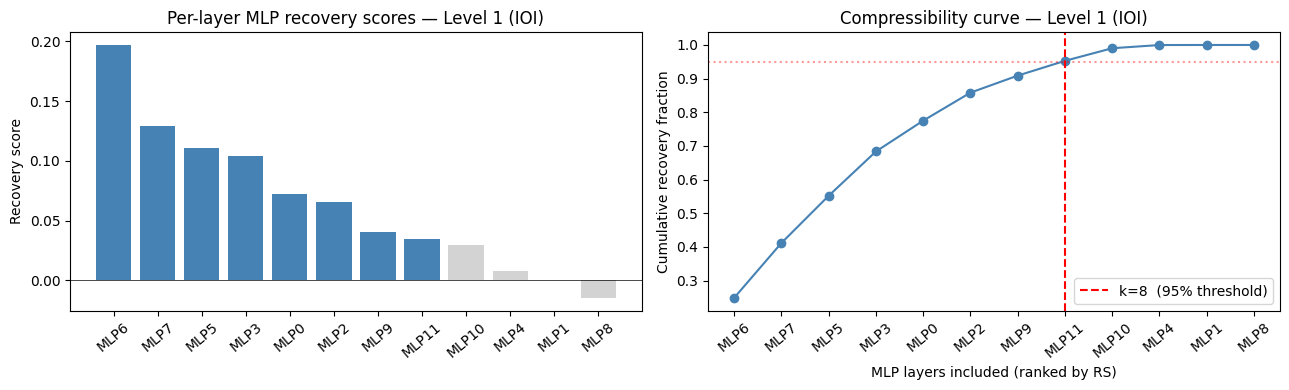

In [12]:
sorted_layers    = sorted(layer_scores.items(), key=lambda x: x[1], reverse=True)
sorted_layer_ids = [x[0] for x in sorted_layers]
sorted_scores    = torch.tensor([x[1] for x in sorted_layers])

pos_scores = sorted_scores.clamp(min=0)
cumulative  = pos_scores.cumsum(0)
total_pos   = cumulative[-1].item()

k_95 = int((cumulative / total_pos >= 0.95).nonzero()[0].item()) + 1
circuit_layers = set(sorted_layer_ids[:k_95])

# Faithfulness of the k_95-layer circuit
all_circuit = []
for start in range(0, n_valid, BATCH_SIZE):
    end = min(start + BATCH_SIZE, n_valid)
    batch_tok = ioi_tokens[start:end]
    batch_fps = final_positions[start:end]
    hooks = []
    for l in range(N_LAYERS):
        if l in circuit_layers:
            clean_acts = clean_mlp_acts[l][start:end].to(device)
            def make_restore(ca=clean_acts, fp=batch_fps):
                def hook_fn(value, hook):
                    batch_size = value.shape[0]
                    value[torch.arange(batch_size, device=value.device), fp] = ca
                    return value
                return hook_fn
            hooks.append((mlp_hook(l), make_restore()))
        else:
            mean = mean_abc_mlp[l].to(device)
            def make_abl(m=mean, fp=batch_fps):
                def hook_fn(value, hook):
                    batch_size = value.shape[0]
                    value[torch.arange(batch_size, device=value.device), fp] = (
                        m.unsqueeze(0).expand(batch_size, -1))
                    return value
                return hook_fn
            hooks.append((mlp_hook(l), make_abl()))
    with torch.no_grad():
        patched = model.run_with_hooks(batch_tok, fwd_hooks=hooks)
        all_circuit.append(patched.cpu())
        del patched
    torch.cuda.empty_cache()

circuit_logits = torch.cat(all_circuit, dim=0).to(device)
circuit_ld     = logit_diff(circuit_logits, ioi_valid, final_positions)
faithfulness   = recovery_score(circuit_ld, corrupted_ld, clean_ld)

print("=" * 55)
print("  Level 1 - MLP layers - IOI task")
print("=" * 55)
print(f"  Criterion 1  Faithfulness RS : {faithfulness:.4f}")
print(f"  Criterion 2  Component count : {k_95} / {N_LAYERS} layers")
print(f"               Compression ratio: {k_95 / N_LAYERS:.3f}")
print(f"  Circuit MLP layers: {sorted(circuit_layers)}")
print("=" * 55)

# Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

colors = ["steelblue" if l in circuit_layers else "lightgray" for l in sorted_layer_ids]
ax1.bar([f"MLP{l}" for l in sorted_layer_ids], sorted_scores.numpy(), color=colors)
ax1.axhline(0, color="black", linewidth=0.5)
ax1.set_ylabel("Recovery score")
ax1.set_title("Per-layer MLP recovery scores — Level 1 (IOI)")
ax1.tick_params(axis="x", rotation=40)

ax2.plot(range(1, N_LAYERS + 1), cumulative.numpy() / total_pos, "o-", color="steelblue")
ax2.axvline(k_95, color="red", linestyle="--", label=f"k={k_95}  (95% threshold)")
ax2.axhline(0.95, color="red", linestyle=":", alpha=0.4)
ax2.set_xlabel("MLP layers included (ranked by RS)")
ax2.set_ylabel("Cumulative recovery fraction")
ax2.set_title("Compressibility curve — Level 1 (IOI)")
ax2.set_xticks(range(1, N_LAYERS + 1))
ax2.set_xticklabels([f"MLP{l}" for l in sorted_layer_ids], rotation=40)
ax2.legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / "level1IOI_recovery_scores.png", dpi=150)
plt.show()

## Notes for thesis

**Criterion 1 (Faithfulness)**: measures how much of the IOI logit-difference gap can be attributed
to MLP neurons alone. The IOI paper found the circuit is primarily in attention heads, so this
number should be substantially lower than the Level 2 result from `03bis`.

**Criterion 2 (Compressibility)**: k_95 / 12 MLP layers needed. If k_95 is large (say 8–10),
the MLP description is diffuse: no small subset of MLP layers captures the IOI computation.
Contrast this with grokking (`02`), where 2–3 Fourier-frequency clusters suffice.

**Interpretation of the gap**: the corrupted LD (all MLPs ablated, attention heads intact) will
remain positive because attention heads do most of the IOI work. The gap is the *marginal*
MLP contribution on top of what attention alone provides. Both faithfulness and RS are relative
to this MLP-only gap.

**Cross-task comparison (grokking vs IOI)**:
- Grokking (`02`): Level 1 Fourier clusters give good faithfulness and sparse compressibility
- IOI (this notebook): Level 1 MLP layers give low faithfulness

In [13]:
results = {
    "level": 1,
    "task": "ioi",
    "method": "mlp_layer_patching",
    "n_layers": N_LAYERS,
    "d_mlp": D_MLP,
    "n_eval": n_valid,
    "clean_ld_mean": clean_ld.mean().item(),
    "corrupted_ld_mean": corrupted_ld.mean().item(),
    "gap": (clean_ld - corrupted_ld).mean().item(),
    "criterion1_faithfulness": faithfulness,
    "criterion2_component_count": k_95,
    "criterion2_compression_ratio": k_95 / N_LAYERS,
    "circuit_layers": sorted(circuit_layers),
    "all_recovery_scores": {str(l): float(s) for l, s in layer_scores.items()},
}

with open(RESULTS_DIR / "level1IOI_results.json", "w") as f:
    json.dump(results, f, indent=2)
print(f"Saved to {RESULTS_DIR}/level1IOI_results.json")

Saved to ..\results\level1IOI/level1IOI_results.json
